In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Negative
df1_neg = pd.read_csv("../eval_results/eval_20260516_131934_reduced.csv") # seed 42
df2_neg = pd.read_csv("../eval_results/eval_20260516_134406_reduced.csv") # seed 43
df3_neg = pd.read_csv("../eval_results/eval_20260516_135721_reduced.csv") # seed 44

# Numeric
df1_num = pd.read_csv("../eval_results/eval_20260516_141951_reduced.csv") # seed 42
df2_num = pd.read_csv("../eval_results/eval_20260516_143911_reduced.csv") # seed 43
df3_num = pd.read_csv("../eval_results/eval_20260516_145500_reduced.csv") # seed 44

# Highly Constrained
df1_high = pd.read_csv("../eval_results/eval_20260516_150847_reduced.csv") # seed 42
df2_high = pd.read_csv("../eval_results/eval_20260516_152102_reduced.csv") # seed 43
df3_high = pd.read_csv("../eval_results/eval_20260516_154232_reduced.csv") # seed 44

# Multi-Recipe
df1_multi = pd.read_csv("../eval_results_planning/eval_20260517_162405_reduced.csv") # seed 42
df2_multi = pd.read_csv("../eval_results_planning/eval_20260517_165311_reduced.csv") # seed 43
df3_multi = pd.read_csv("../eval_results_planning/eval_20260517_172130_reduced.csv") # seed 44

In [3]:
# Group datasets
datasets = {
    "Negative": [df1_neg, df2_neg, df3_neg],
    "Numeric": [df1_num, df2_num, df3_num],
    "Highly Constrained": [df1_high, df2_high, df3_high],
    "Multi-Recipe": [df1_multi, df2_multi, df3_multi]
}

numeric_cols = [
    "faithfulness",
    "context_precision",
    "constraint_satisfaction"
]

# First: compute per-dataframe means for each numeric column
per_seed_means = {}

for dataset_name, dfs in datasets.items():
    per_seed_means[dataset_name] = []

    for i, df in enumerate(dfs, start=1):
        means = df[numeric_cols].mean()
        per_seed_means[dataset_name].append(means)

# Then: aggregate across the 3 seeds
summary_stats = {}

for dataset_name, seed_means_list in per_seed_means.items():
    # Combine seed means into a dataframe
    seed_means_df = pd.DataFrame(seed_means_list)

    # Mean across seeds
    mean_across_seeds = seed_means_df.mean()

    # Std across seeds
    std_across_seeds = seed_means_df.std()

    summary_stats[dataset_name] = pd.DataFrame({
        "mean_across_seeds": mean_across_seeds,
        "std_across_seeds": std_across_seeds
    })

    print(f"\n=== {dataset_name} ===")
    print(summary_stats[dataset_name])


=== Negative ===
                         mean_across_seeds  std_across_seeds
faithfulness                      0.881919          0.026837
context_precision                 0.593333          0.018903
constraint_satisfaction           0.985669          0.007946

=== Numeric ===
                         mean_across_seeds  std_across_seeds
faithfulness                      0.791826          0.043973
context_precision                 0.470667          0.030551
constraint_satisfaction           0.920065          0.023918

=== Highly Constrained ===
                         mean_across_seeds  std_across_seeds
faithfulness                      0.731396          0.063109
context_precision                 0.233333          0.010066
constraint_satisfaction           0.867941          0.042057

=== Multi-Recipe ===
                         mean_across_seeds  std_across_seeds
faithfulness                      0.754612          0.048497
context_precision                 0.653725          0.007147


In [4]:
plot_data = []

for dataset_name, dfs in datasets.items():
    combined = pd.concat(dfs, axis=0, ignore_index=True)
    
    temp = pd.DataFrame({
        "dataset": dataset_name,
        "faithfulness": combined["faithfulness"],
        "precision": combined["context_precision"],
        "CSR": combined["constraint_satisfaction"]
    })
    
    plot_data.append(temp)

plot_data = pd.concat(plot_data, axis=0, ignore_index=True)

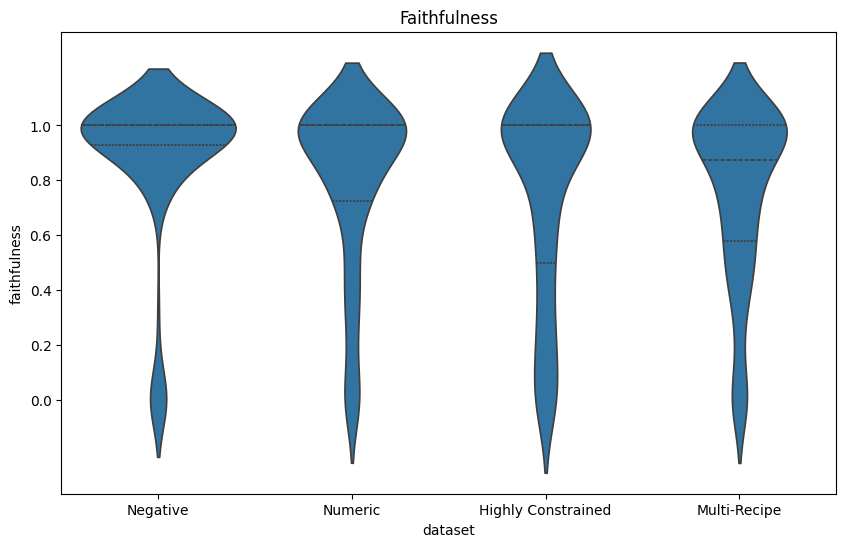

In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x="dataset", y="faithfulness", inner="quartile")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.title("Faithfulness")
plt.show()

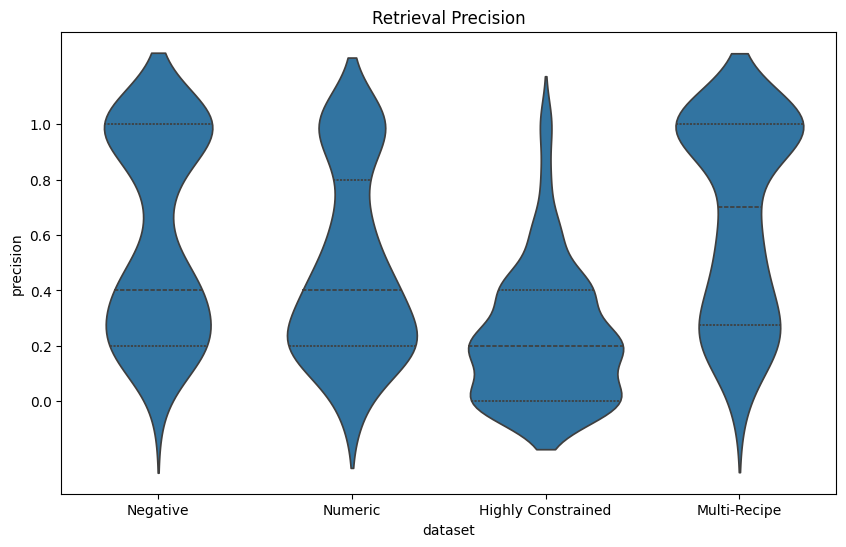

In [6]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x="dataset", y="precision", inner="quartile")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.title("Retrieval Precision")
plt.show()

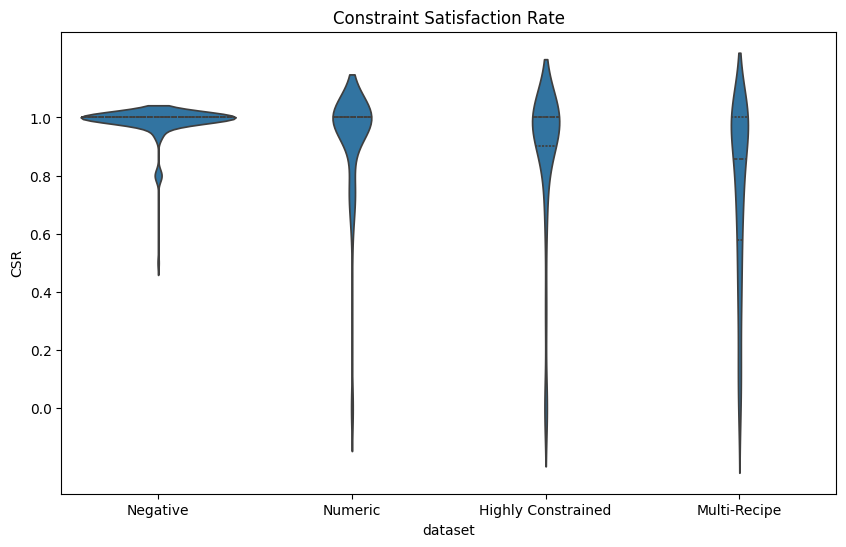

In [8]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x="dataset", y="CSR", inner="quartile")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.title("Constraint Satisfaction Rate")
plt.show()